In [1]:
import functools
import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from tqdm.notebook import trange, tqdm
from torchvision.datasets import FashionMNIST
from torch.optim import Adam
from torch.utils.data import DataLoader

In [2]:
device = torch.device('cuda')
torch.backends.cudnn.benchmark = True
device

device(type='cuda')

References:

- [[Song21]](https://openreview.net/pdf?id=PxTIG12RRHS) Score-Based Generative Modeling Through Stochastic Differential Equations
- Yang Song's blog

## Variance Preserving SDE (VP)

Variance Preserving diffusion SDE (Eq 11 in [Song21]):

\begin{align*}
d \mathbf{x} = - \frac{1}{2} \beta(t) \mathbf{x} dt + \sqrt{\beta(t)}d\mathbf{w}
\end{align*}

This follows the general SDE form $d \mathbf{x} = f(\mathbf{x}, t) dt + g(t) d \mathbf{w}$. We call $f(\mathbf{x}, t)$ the **drift coefficient** and $g(t)$ the **diffusion coefficient**.

The corresponding general conditional linear Gaussian distribution is:
\begin{align*}
p(x_t|x_0) = \mathcal{N}(x_t; \alpha(t)x_0, \sigma^2(t)I)
\end{align*}
where $\alpha: [0,1] \rightarrow \mathbb{R}$,  $\sigma: [0,1] \rightarrow \mathbb{R}$

$\mu(t), \sigma(t)$ can be derived analytically from $f(\mathbf{x}, t), g(t)$.

\begin{align*}
\begin{cases}
  \mu(t) = \alpha(t)x_0 = \exp{(c(t))}x_0 \\
  \sigma^2(t) = 1 - \exp(2c(t))
\end{cases}
\end{align*}

### Implementing the VP SDE

Refer to Equations (32) and (33) in [Song21] to identify:
* $\beta(t)$
* $c(t)$
* $\mu(t)$
* $\sigma(t)$

Copy your code from `vp.py`

In [3]:
import torch
import math

class VP():
    def __init__(self, beta_min, beta_max, num_steps):
        self.beta_0 = beta_min
        self.beta_1 = beta_max
        self.num_steps = num_steps
        self.discrete_betas = torch.linspace(beta_min / num_steps, beta_max / num_steps, num_steps)
        self.alphas = 1. - self.discrete_betas

    def _beta_t(self, t):
        '''
        Caculate beta_t for a array of t.
        Args:
            - t (torch.Tensor): array of t, shape (N,)
        Returns:
            - beta_t (torch.Tensor): array of beta_t, shape (N,)
        '''
        # β(t) = β_0 + (β_1 - β_0) * t   [Eq. 32 of Song21]
        return self.beta_0 + (self.beta_1 - self.beta_0) * t

    def _c_t(self, t):
        '''
        Calculat c_t for a array of t.
        Args:
            - t (torch.Tensor): array of t, shape (N,)
        Returns:
            - c_t (torch.Tensor): array of c_t, shape (N,)
        '''
        # c(t) = -1/2 * ∫_0^t β(s)ds = -1/2 * (β_0*t + 1/2*(β_1-β_0)*t²)  [Eq. 33]
        return -0.5 * (self.beta_0 * t + 0.5 * (self.beta_1 - self.beta_0) * t ** 2)

    def marginal_prob(self, x, t):
        '''
        Compute the mean and standard deviation of the conditional distribution p(x_t|x_0).
        Args:
            - x (torch.Tensor | scalar): input, shape (N, C, H, W) or 0 for init queries
            - t (torch.Tensor | float): time, shape (N,) or scalar
        Returns:
            - mu_t:  mean,  shape (N, C, H, W)  [or scalar when x=0]
            - std_t: std,   shape (N,)           [or scalar when t is scalar]
        '''
        c_t = self._c_t(t)
        if isinstance(c_t, torch.Tensor):
            alpha_t = torch.exp(c_t)
            std_t = torch.sqrt(1. - torch.exp(2. * c_t))
        else:
            alpha_t = math.exp(c_t)
            std_t = math.sqrt(max(0., 1. - math.exp(2. * c_t)))

        if isinstance(x, torch.Tensor) and x.dim() >= 2:
            view_shape = (-1,) + (1,) * (x.dim() - 1)
            mu_t = alpha_t.view(*view_shape) * x
        else:
            mu_t = alpha_t * x
        return mu_t, std_t

    # alias used throughout the notebook
    marginal_proba = marginal_prob

    def drift(self, x, t):
        '''
        Compute the VP drift coefficient f(x, t) = -½ β(t) x
        Args:
            - x (torch.Tensor): input tensor, shape (N, C, H, W)
            - t (torch.Tensor): array of t, shape (N,)
        Returns:
            - drift (torch.Tensor): drift term, shape (N, C, H, W)
        '''
        beta_t = self._beta_t(t)
        if isinstance(beta_t, torch.Tensor):
            view_shape = (-1,) + (1,) * (x.dim() - 1)
            return -0.5 * beta_t.view(*view_shape) * x
        return -0.5 * beta_t * x

    def diffusion(self, t):
        '''
        Compute the VP diffusion coefficient g(t) = √β(t)
        Args:
            - t (torch.Tensor): array of t, shape (N,)
        Returns:
            - diffusion (torch.Tensor): diffusion term, shape (N,)
        '''
        beta_t = self._beta_t(t)
        if isinstance(beta_t, torch.Tensor):
            return torch.sqrt(beta_t)
        return math.sqrt(beta_t)

## Sampling with VP sde

As per Appendix E of [Song21], recall that for any SDE of the form
\begin{align*}
d \mathbf{x} = \mathbf{f}(\mathbf{x}, t) dt + g(t) d\mathbf{w},
\end{align*}
the reverse-time SDE is given by
\begin{align*}
d \mathbf{x} = [\mathbf{f}(\mathbf{x}, t) - g(t)^2 \nabla_\mathbf{x} \log p_t(\mathbf{x})] dt + g(t) d \bar{\mathbf{w}}.
\end{align*}

We use the [Euler-Maruyama](https://en.wikipedia.org/wiki/Euler%E2%80%93Maruyama_method) numerical method to solve for the reverse-time SDE. This method relies on discretizing the SDE, replacing $dt$ with $\Delta t$ and $d \mathbf{w}$ with $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, g^2(t) \Delta t \mathbf{I})$.

This lead to the following iteration rule:
\begin{align}
\mathbf{x}_{t-\Delta t} =
\mathbf{x}_t
- \mathbf{f}(\mathbf{x}_t, t)\Delta t
+ g^2(t) s_\theta(\mathbf{x}_t, t)\Delta t
+ g(t)\sqrt{\Delta_t}\mathbf{z}_t.
\end{align}

Note: for the last step (i.e. $t-\Delta_t = 0$), we do not wish to add back noise ($g(t)\sqrt{\Delta_t}\mathbf{z}_t$).

In [4]:
def Euler_Maruyama_sampler(score_model,
                           sde,
                           batch_size,
                           num_steps=1000,
                           device='cuda',
                           eps=1e-3):
    '''
    Euler-Maruyama sampler for SDEs.
    Args:
        - score_model (nn.Module): score-based model
        - sde (SDE): SDE, VP class
        - batch_size (int): batch size
        - num_steps (int): number of time steps
        - device (str): device
        - eps (float): truncation time to avoid numerical instability
    Returns:
        - x_next (torch.Tensor): samples from the SDE, shape (batch_size, 1, 28, 28)
    '''
    # Initialise x(t=1) ~ N(0, σ(1)² I)
    t1 = torch.ones(batch_size, device=device)
    _, std_1 = sde.marginal_prob(torch.zeros(batch_size, 1, 28, 28, device=device), t1)
    init_x = torch.randn(batch_size, 1, 28, 28, device=device) * std_1[:, None, None, None]

    # Time grid from 1 down to eps with num_steps uniform points
    time_steps = torch.linspace(1., eps, num_steps, device=device)

    step_size = time_steps[0] - time_steps[1]

    x_next = init_x
    with torch.no_grad():
        for time_step in tqdm(time_steps):
            batch_time = torch.ones(batch_size, device=device) * time_step

            score = score_model(x_next, batch_time)          # s_θ(x_t, t)
            g_t   = sde.diffusion(batch_time)                # √β(t),  shape (B,)
            f_xt  = sde.drift(x_next, batch_time)            # -½β(t)x, shape (B,1,28,28)

            # Reverse-SDE mean: x - f(x,t)Δt + g²(t)·s_θ·Δt
            mean_x = x_next - f_xt * step_size + g_t[:, None, None, None] ** 2 * score * step_size

            # Add diffusion noise everywhere except the very last step
            if time_step > eps:
                x_next = mean_x + g_t[:, None, None, None] * torch.sqrt(step_size) * torch.randn_like(x_next)
            else:
                x_next = mean_x
    return x_next

In [6]:
def predictor_corrector_sampler(score_model,
                                sde,
                                batch_size,
                                num_steps=1000,
                                device='cuda',
                                snr=0.16,
                                num_corrector_steps=1,
                                eps=1e-3):
    '''
    Predictor-corrector sampler for SDEs.
    Args:
        - score_model (nn.Module): score-based model
        - sde (SDE): SDE, VP class
        - batch_size (int): batch size
        - num_steps (int): number of time steps
        - device (str): device
        - snr (float): signal-to-noise ratio
        - num_corrector_steps (int): number of corrector steps
        - eps (float): truncation time to avoid numerical instability
    '''
    # Initialise x(t=1) ~ N(0, σ(1)² I)
    t1 = torch.ones(batch_size, device=device)
    _, std_1 = sde.marginal_prob(torch.zeros(batch_size, 1, 28, 28, device=device), t1)
    init_x = torch.randn(batch_size, 1, 28, 28, device=device) * std_1[:, None, None, None]

    # Time grid from 1 down to eps
    time_steps = torch.linspace(1., eps, num_steps, device=device)

    step_size = time_steps[0] - time_steps[1]

    x_next = init_x
    with torch.no_grad():
        for time_step in tqdm(time_steps):
            batch_time_steps = torch.ones(batch_size, device=device) * time_step
            int_time_step = int(time_step * (sde.num_steps - 1))
            alpha_t = sde.alphas[int_time_step]

            # ── Corrector: annealed Langevin dynamics (Algorithm 5 of Song21) ──
            for j in range(num_corrector_steps):
                score = score_model(x_next, batch_time_steps)
                noise = torch.randn_like(x_next)

                # Per-sample SNR-based step size: ε = 2α * (snr * ||z||/||s||)²
                score_norm = torch.norm(score.reshape(batch_size, -1), dim=-1)
                noise_norm = torch.norm(noise.reshape(batch_size, -1), dim=-1)
                langevin_step = 2 * alpha_t * (snr * noise_norm / score_norm.clamp(min=1e-8)) ** 2

                x_next = (x_next
                          + langevin_step[:, None, None, None] * score
                          + torch.sqrt(2 * langevin_step[:, None, None, None]) * noise)

            # ── Predictor: one Euler-Maruyama reverse step ───────────────────
            score = score_model(x_next, batch_time_steps)
            g_t  = sde.diffusion(batch_time_steps)          # shape (B,)
            f_xt = sde.drift(x_next, batch_time_steps)      # shape (B,1,28,28)

            mean_x = x_next - f_xt * step_size + g_t[:, None, None, None] ** 2 * score * step_size

            if time_step > eps:
                x_next = mean_x + g_t[:, None, None, None] * torch.sqrt(step_size) * torch.randn_like(x_next)
            else:
                x_next = mean_x
    return x_next

## Setup -- no TODOs to fill in here :)

### Config

In [5]:
n_epochs = 50
batch_size = 64
lr = 1e-4
num_steps=1000
checkpoint_dir = './checkpoints/'

### Dataset

In [6]:
# training dataset
train_transforms = transforms.Compose([transforms.ToTensor()])
train_dataset = FashionMNIST('.', train=True, transform=train_transforms, download=True);
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 175kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.30MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.5MB/s]


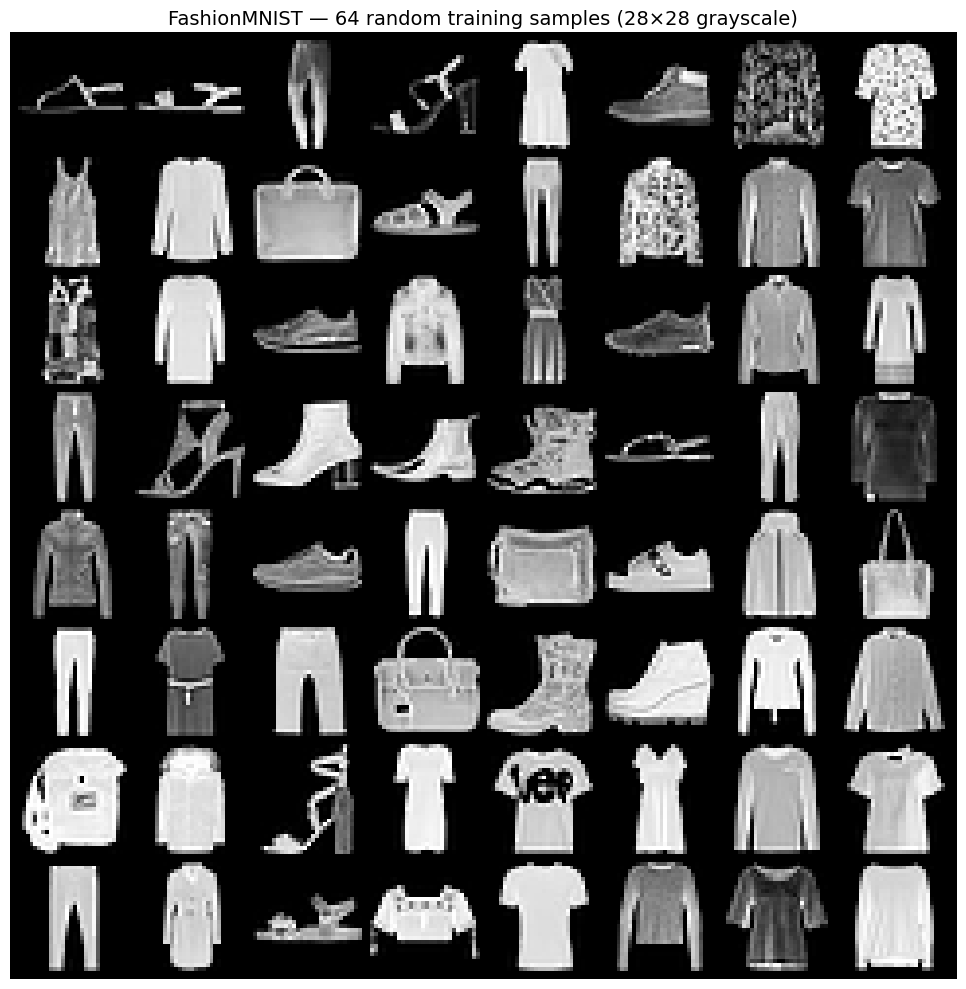

Image shape: torch.Size([64, 1, 28, 28])
Classes: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot


In [20]:
# Problem 5.C.i: Dataset Visualization — 64 FashionMNIST samples
from torchvision.utils import make_grid

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

images, labels = next(iter(DataLoader(train_dataset, batch_size=64, shuffle=True)))

grid = make_grid(images, nrow=8, padding=2, normalize=True)

plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title('FashionMNIST — 64 random training samples (28×28 grayscale)', fontsize=14)
plt.tight_layout()
plt.show()

print("Image shape:", images.shape)   # (64, 1, 28, 28)
print("Classes:", ', '.join(class_names))

### Score-matching model

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class GaussianFourierProjection(nn.Module):
    """Gaussian random features for encoding time steps."""
    def __init__(self, embed_dim, scale=30.):
        super().__init__()
        # Randomly sample weights during initialization. These weights are fixed
        # during optimization and are not trainable.
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)


class Dense(nn.Module):
    """A fully connected layer that reshapes outputs to feature maps."""
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.dense = nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.dense(x)[..., None, None]


class ScoreNet(nn.Module):
    """A time-dependent score-based model built upon U-Net architecture."""

    def __init__(self, marginal_proba, channels=[32, 64, 128, 256], embed_dim=256):
        """Initialize a time-dependent score-based network.

        Args:
          marginal_proba: A function that takes time t and gives the standard
            deviation of the perturbation kernel p_{0t}(x(t) | x(0)).
          channels: The number of channels for feature maps of each resolution.
          embed_dim: The dimensionality of Gaussian random feature embeddings.
        """
        super().__init__()
        # Gaussian random feature embedding layer for time
        self.embed = nn.Sequential(GaussianFourierProjection(embed_dim=embed_dim),
             nn.Linear(embed_dim, embed_dim))
        # Encoding layers where the resolution decreases
        self.conv1 = nn.Conv2d(1, channels[0], 3, stride=1, bias=False)
        self.dense1 = Dense(embed_dim, channels[0])
        self.gnorm1 = nn.GroupNorm(4, num_channels=channels[0])
        self.conv2 = nn.Conv2d(channels[0], channels[1], 3, stride=2, bias=False)
        self.dense2 = Dense(embed_dim, channels[1])
        self.gnorm2 = nn.GroupNorm(32, num_channels=channels[1])
        self.conv3 = nn.Conv2d(channels[1], channels[2], 3, stride=2, bias=False)
        self.dense3 = Dense(embed_dim, channels[2])
        self.gnorm3 = nn.GroupNorm(32, num_channels=channels[2])
        self.conv4 = nn.Conv2d(channels[2], channels[3], 3, stride=2, bias=False)
        self.dense4 = Dense(embed_dim, channels[3])
        self.gnorm4 = nn.GroupNorm(32, num_channels=channels[3])

        # Decoding layers where the resolution increases
        self.tconv4 = nn.ConvTranspose2d(channels[3], channels[2], 3, stride=2, bias=False)
        self.dense5 = Dense(embed_dim, channels[2])
        self.tgnorm4 = nn.GroupNorm(32, num_channels=channels[2])
        self.tconv3 = nn.ConvTranspose2d(channels[2] + channels[2], channels[1], 3, stride=2, bias=False, output_padding=1)
        self.dense6 = Dense(embed_dim, channels[1])
        self.tgnorm3 = nn.GroupNorm(32, num_channels=channels[1])
        self.tconv2 = nn.ConvTranspose2d(channels[1] + channels[1], channels[0], 3, stride=2, bias=False, output_padding=1)
        self.dense7 = Dense(embed_dim, channels[0])
        self.tgnorm2 = nn.GroupNorm(32, num_channels=channels[0])
        self.tconv1 = nn.ConvTranspose2d(channels[0] + channels[0], 1, 3, stride=1)

        # The swish activation function
        self.act = lambda x: x * torch.sigmoid(x)
        self.marginal_proba = marginal_proba

    def forward(self, x, t):
        # Obtain the Gaussian random feature embedding for t
        embed = self.act(self.embed(t))
        # Encoding path
        h1 = self.conv1(x)
        ## Incorporate information from t
        h1 += self.dense1(embed)
        ## Group normalization
        h1 = self.gnorm1(h1)
        h1 = self.act(h1)
        h2 = self.conv2(h1)
        h2 += self.dense2(embed)
        h2 = self.gnorm2(h2)
        h2 = self.act(h2)
        h3 = self.conv3(h2)
        h3 += self.dense3(embed)
        h3 = self.gnorm3(h3)
        h3 = self.act(h3)
        h4 = self.conv4(h3)
        h4 += self.dense4(embed)
        h4 = self.gnorm4(h4)
        h4 = self.act(h4)

        # Decoding path
        h = self.tconv4(h4)
        ## Skip connection from the encoding path
        h += self.dense5(embed)
        h = self.tgnorm4(h)
        h = self.act(h)
        h = self.tconv3(torch.cat([h, h3], dim=1))
        h += self.dense6(embed)
        h = self.tgnorm3(h)
        h = self.act(h)
        h = self.tconv2(torch.cat([h, h2], dim=1))
        h += self.dense7(embed)
        h = self.tgnorm2(h)
        h = self.act(h)
        h = self.tconv1(torch.cat([h, h1], dim=1))

        # Normalize output
        _, std = self.marginal_proba(x, t)
        h = h / std[:, None, None, None]
        return h

### Loss function

In [8]:
def loss_fn(model, x, sde, eps=1e-5):
    """ Inputs:
          model: score model (i.e. diffusion model)
          x: batch of images
          sde: instance of VP class
          eps: parameter for numerical stability (1e-5 for learning, 1e-3 for sampling)
    """
    random_t = torch.rand(x.shape[0], device=x.device) * (1. - eps) + eps
    z = torch.randn_like(x, device=x.device)
    mean, std = sde.marginal_proba(x, random_t)
    perturbed_x = mean + z * std[:, None, None, None]

    # predict the score function for each perturbed x in the batch and its corresponding random t
    score = model(perturbed_x, random_t)

    # compute loss
    losses = score * std[:, None, None, None] + z
    loss = torch.mean(torch.sum(losses**2, dim=(1,2,3)))
    return loss

## Train the score model

In [9]:
# VP sde
def train(sde_params):
    beta_min, beta_max = sde_params
    sde = VP(beta_min, beta_max, num_steps)

    score_model = ScoreNet(marginal_proba=sde.marginal_proba)
    score_model = score_model.to(device)
    optimizer = Adam(score_model.parameters(), lr=lr)

    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)
    params_str = '{}_{}'.format(beta_min, beta_max)
    checkpoint_path = checkpoint_dir+'ckpt_{}_{}epochs_{}.pth'.format("fashionmnist", n_epochs, params_str)

    # load checkpoint if existing
    if os.path.exists(checkpoint_path):
        score_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        print("model loaded from checkpoint!")
    # otherwise train from scratch
    else:
        losses = []
        patience = 0
        tqdm_epoch = trange(n_epochs)
        for epoch in tqdm_epoch:
            avg_loss = 0.
            num_items = 0
            for x, y in train_loader:
                x = x.to(device)
                loss = loss_fn(score_model, x, sde)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                avg_loss += loss.item() * x.shape[0]
                num_items += x.shape[0]
            tqdm_epoch.set_description('Average Loss: {:5f}'.format(avg_loss / num_items))
            losses.append(avg_loss/ num_items)

            # Saving: loss need to decrease by 2pts
            if len(losses)>=2:
                if losses[-2] - losses[-1] >= 0.5:
                    torch.save(score_model.state_dict(), checkpoint_path)
                    patience = 0
                else:
                    patience +=1

            # Patience: if no significant improvement in 3 epochs, early stopping
            if patience >= 3:
                break

        plt.plot(range(len(losses)), losses)
        plt.yscale('log')
        plt.show()
    return score_model

## Generation of new samples

In [10]:
from torchvision.utils import make_grid
def plot_images(images):
    sample_grid = make_grid(images, nrow=int(np.sqrt(images.shape[0])))
    plt.figure(figsize=(6,6))
    plt.axis('off')
    plt.imshow(sample_grid.cpu().permute(1, 2, 0).squeeze())
    plt.show()

In [11]:
def setup_for_sampling(sde_params):
    beta_min, beta_max = sde_params
    params_str = '{}_{}'.format(beta_min, beta_max)
    checkpoint_path = checkpoint_dir+'ckpt_{}_{}epochs_{}.pth'.format("fashionmnist", n_epochs, params_str)

    sde = VP(beta_min, beta_max, num_steps)
    score_model = ScoreNet(marginal_proba=sde.marginal_proba)
    score_model = score_model.to(device)
    score_model.eval()
    score_model.load_state_dict(torch.load(checkpoint_path, map_location=device))

    return sde, score_model

### Sampling

  0%|          | 0/50 [00:00<?, ?it/s]

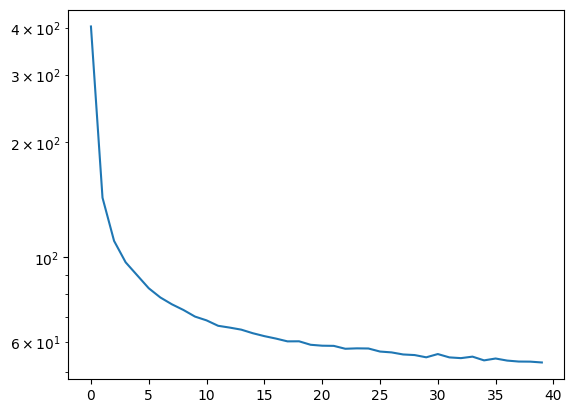

In [ ]:
sde_params = [0.01, 5.0]
score_model = train(sde_params)

In [16]:
beta_min, beta_max = sde_params
sde = VP(beta_min, beta_max, num_steps)

  0%|          | 0/1000 [00:00<?, ?it/s]

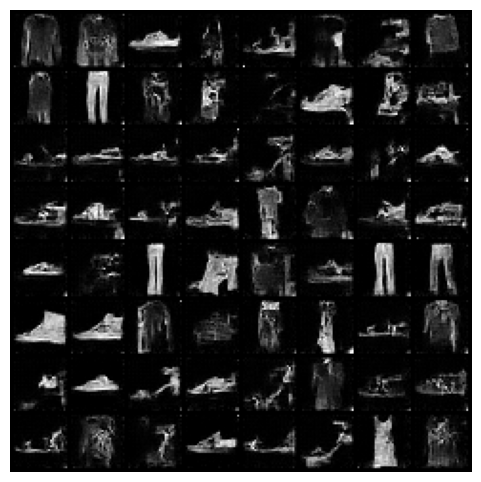

In [17]:
samples = Euler_Maruyama_sampler(score_model, sde, batch_size, num_steps=1000)
plot_images(samples)

  0%|          | 0/1000 [00:00<?, ?it/s]

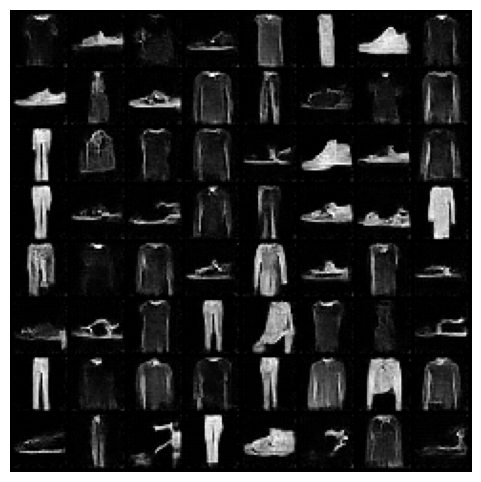

In [18]:
samples = predictor_corrector_sampler(score_model, sde, batch_size, num_steps=1000)
plot_images(samples)

  0%|          | 0/1000 [00:00<?, ?it/s]

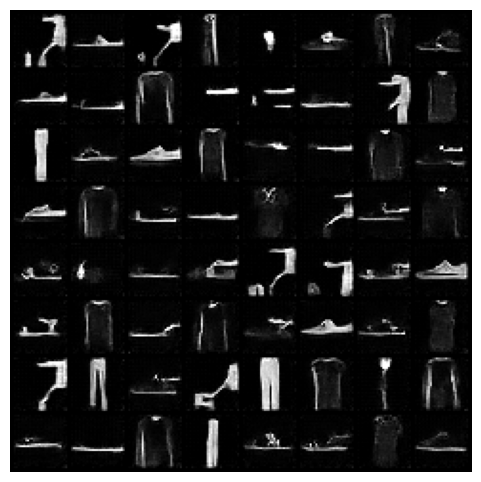

In [19]:
samples = predictor_corrector_sampler(score_model, sde, batch_size, num_corrector_steps=5, num_steps=1000)
plot_images(samples)

# Part 4D: Diffusion models for inverse problems

## EC (10pts) : inpainting -- keep until you're done with the pset
This part will require you to read and understand [[Song22]](https://arxiv.org/pdf/2111.08005.pdf) Solving Inverse Problems In Medical Imaging With Score-Based Generative Models.

In our toy example, our measurement matrix A will be an explicit inpainting matrix that replaces some of the pixels in an image by 0 (blackening them out).

Your job will be to modify the sampling process to include conditioning on the perturbed measurements at various t.

**Important: do not attempt until you are entirely satisfied with your work for all of the rest of the assignment (Parts 1 through 5).**

**Important: Minimum guidance will be provided in OH or on Piazza. 🎶🎵You're on your own, kid. You always have been🎵🎶**

**Expectations:** The expected result is a plot with 3 rows: clean images, inpainted images, reconstructed images. The plot **must** include the PSNR of each reconstructed image. You should use at least 5 clean images. We wrote the plotting function for you. We also expect you to explain and justify your implementation choices. Everything (plot, explanations, justifications) **must** appear in your submission PDF.

In [21]:
# helper function to inpaint with 0 pixels and get the subsampling matrix
def inpaint(images, ratio=0.05):
    num_pixels = images.shape[-2] * images.shape[-1]
    num_samples = int(ratio * num_pixels)
    # create subsampling matrix A
    A = torch.eye(num_pixels, device=images.device)
    for pixel in random.sample(range(0, num_pixels), num_samples):
        A[pixel][pixel] = 0
    # black out pixels in images using A (a binary matrix with zeroes where we want to black out pixels)
    inpainted_images = images.clone()
    for i in range(len(images)):
        inpainted_images[i] = torch.reshape(torch.matmul(A, inpainted_images[i].view(num_pixels)), images[0].shape)
    return inpainted_images, A

In [22]:
# helper function to compute the peak signal-to-noise ratio (PSNR)
def psnr(clean, noisy):
    # our range of values is [0.,1.]
    eps = 1e-8
    mse = torch.mean((clean - noisy) ** 2)
    psnr = 10 * torch.log10(1.0 / (mse + eps))
    return psnr

In [23]:
# helper function to plot samples
def plot_before_after(clean_images, imgs_before, imgs_after, title=""):
    assert(imgs_before.shape[0] == imgs_after.shape[0])
    fig, axs = plt.subplots(3, imgs_before.shape[0], figsize=(16, 10))
    # plot 3 rows: clean, then subsampled, then denoised
    for i, images in enumerate([clean_images, imgs_before, imgs_after]):
        for j, image in enumerate(images):
            axs[i][j].imshow(image.cpu().permute(1, 2, 0).squeeze())
            axs[i][j].set_xticks([])
            axs[i][j].set_yticks([])
    # compute PSNR
    for j, image in enumerate(imgs_after):
        clean = clean_images[j].cpu().permute(1,2,0).squeeze()
        noisy = image.cpu().permute(1,2,0).squeeze()
        psnr_val = psnr(clean, noisy).item()
        axs[2][j].set_title('PSNR: {:.3f}'.format(psnr_val), y=-0.2)
    fig.suptitle(title, size=20)

In [28]:
# helper functions to condition the reverse diffusion
def get_y_t(images, t, marginal_proba):
    # vector of t
    ts = t * torch.ones(images.shape[0], device=images.device)
    ts = ts[:, None, None, None]

    # sample some noise
    z = torch.randn_like(images)

    # perturb at level t
    _, std = marginal_proba(x=0, t=t)
    perturbed_images = images + z * std
    return perturbed_images

def lbda_scheduler(t, lbda, param):
    param = torch.tensor(param)
    f_t = param*t
    lbda = lbda * f_t
    return lbda

def condition_on_inpainted_y(raw_images, x_t, t, marginal_prob_std, A, lbda=.01, lbda_param=10):
    y_t = get_y_t(raw_images, t, marginal_prob_std)
    lbda = lbda_scheduler(t, lbda, param=lbda_param)
    # P_inv: pseudo-inverse of the measurement noise covariance — identity for zero-noise inpainting.
    # T:     identity transition (the current x_t is used directly for unknown pixels).
    num_pixels = A.shape[0]
    dev = x_t.device
    P_inv = torch.eye(num_pixels, device=dev)
    T     = torch.eye(num_pixels, device=dev)
    A     = A.to(dev)
    # Expand scalar lbda to batch vector so lbda[:, None] gives shape (B, 1),
    # and move to the correct device (lbda_scheduler creates tensors on CPU).
    if lbda.dim() == 0:
        lbda = lbda.unsqueeze(0).expand(x_t.shape[0])
    lbda = lbda.to(dev)
    # turn images into column vectors
    flat_y_t = torch.flatten(y_t, start_dim=1)
    flat_x_t = torch.flatten(x_t, start_dim=1)
    lbda = lbda[:, None]
    # x_prime is a weighted function of x and y
    y_influence = lbda * torch.matmul(A, torch.matmul(P_inv, flat_y_t.T)).T
    x_influence = (1 - lbda) * torch.matmul(A, torch.matmul(T, flat_x_t.T)).T + \
                  torch.matmul(torch.eye(A.shape[0], device=A.device) - A,
                               torch.matmul(T, flat_x_t.T)).T
    x_t_prime = torch.reshape(y_influence + x_influence, x_t.shape)
    return x_t_prime


def conditional_reverse_diffusion(score_model, sde, clean_images, A,
                                  num_steps=1000, device='cuda', eps=1e-3):
    """Reverse diffusion conditioned on inpainting observations (Song22)."""
    batch_size = clean_images.shape[0]

    # Initialise x(t=1) ~ N(0, σ(1)² I)
    t1 = torch.ones(batch_size, device=device)
    _, std_1 = sde.marginal_prob(torch.zeros(batch_size, 1, 28, 28, device=device), t1)
    x = torch.randn(batch_size, 1, 28, 28, device=device) * std_1[:, None, None, None]

    time_steps = torch.linspace(1., eps, num_steps, device=device)
    step_size  = time_steps[0] - time_steps[1]

    with torch.no_grad():
        for time_step in tqdm(time_steps):
            t_val      = time_step.item()           # scalar float for marginal_prob / lbda_scheduler
            batch_time = torch.ones(batch_size, device=device) * time_step

            # EM reverse step
            score = score_model(x, batch_time)
            g_t   = sde.diffusion(batch_time)                   # (B,)
            f_xt  = sde.drift(x, batch_time)                    # (B,1,28,28)
            mean_x = x - f_xt * step_size + g_t[:, None, None, None] ** 2 * score * step_size
            if time_step > eps:
                x = mean_x + g_t[:, None, None, None] * torch.sqrt(step_size) * torch.randn_like(x)
            else:
                x = mean_x

            # Condition on known pixels at every step
            x = condition_on_inpainted_y(clean_images, x, t_val, sde.marginal_prob, A)

    return x

  0%|          | 0/1000 [00:00<?, ?it/s]

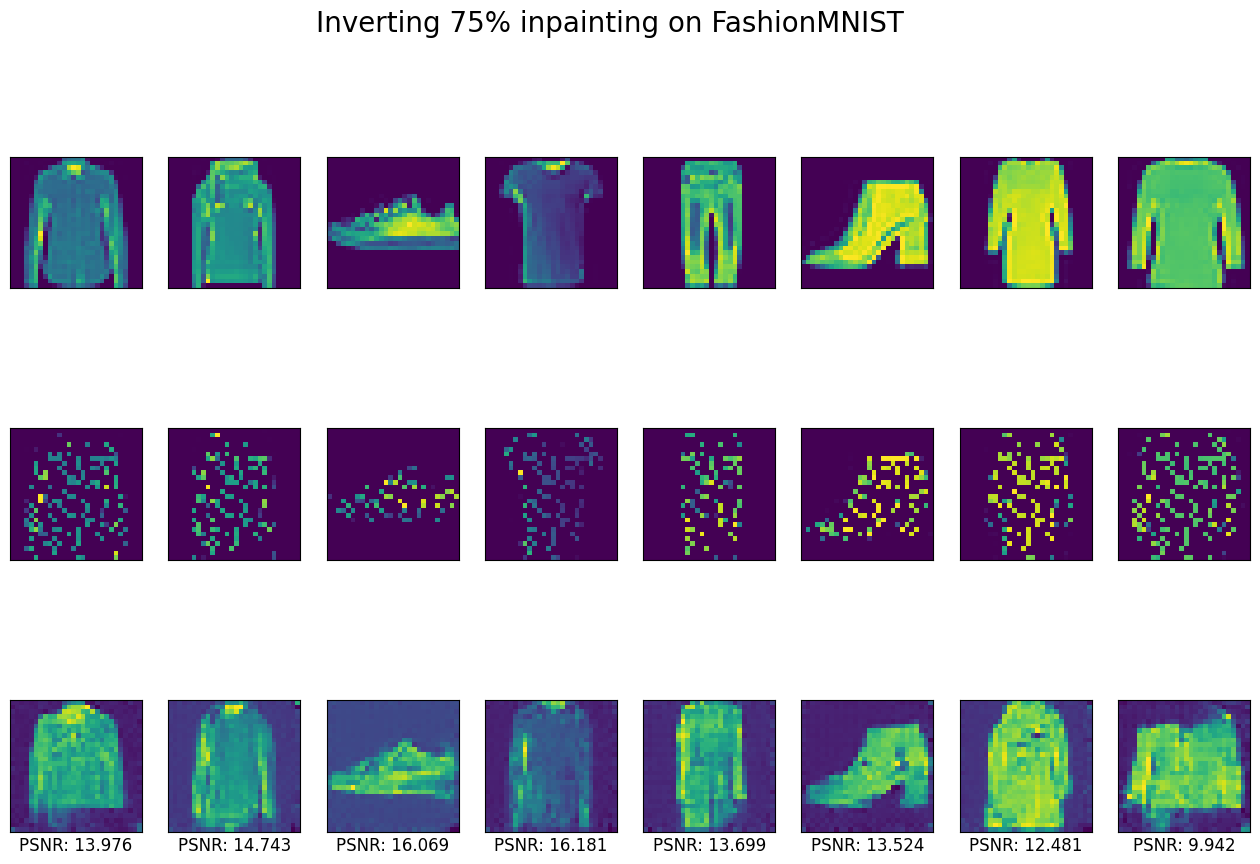

In [29]:
# Inpainted images
num_images = 8
data, _ = next(iter(train_loader))
clean_images = data[:num_images].to(device)
corrupted_images, A = inpaint(clean_images, ratio=0.75)

# Recover via conditioned reverse diffusion
recovered_images = conditional_reverse_diffusion(score_model, sde, clean_images, A, device=device)

# Expected plot
plot_before_after(clean_images, corrupted_images, recovered_images, title="Inverting 75% inpainting on FashionMNIST")

# Part 6: Rectified Flow

## Problem 6.A: Forward Process, Training Loss, and Combined Loss Curves

The forward process and loss are implemented in `diffusion/rectflow.py` and trained via
`scripts/train_rectflow.py`.  Run training with:

```
python scripts/train_rectflow.py --epochs 50 --save_dir runs/rectflow
```

The cell below loads the saved loss arrays and plots both VP and Rectified Flow curves together.

In [13]:
!git clone https://github.com/wduan10/cs148_hw4.git
%cd cs148_hw4

Cloning into 'cs148_hw4'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 51 (delta 8), reused 49 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 1.07 MiB | 32.36 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/cs148_hw4


In [40]:
!git pull

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 603 bytes | 603.00 KiB/s, done.
From https://github.com/wduan10/cs148_hw4
   b7d547e..28e5b5c  main       -> origin/main
Updating b7d547e..28e5b5c
Fast-forward
 scripts/train_vp.py | 13 +++++++++----
 1 file changed, 9 insertions(+), 4 deletions(-)


In [16]:
import os, glob

# Fix NumPy 2.x incompatibility with torch in Colab
!pip install "numpy<2.0" -q

# Locate the hw4 repo root
hits = glob.glob("/content/**/scripts/train_vp.py", recursive=True)
if hits:
    hw4_root = os.path.dirname(os.path.dirname(hits[0]))
    %cd {hw4_root}
else:
    print("⚠️  Could not find train_vp.py — make sure the hw4 repo is cloned under /content")

# Install the diffusion package (skip deps to avoid torch/torchvision conflicts)
!pip install -e . --no-deps -q

os.makedirs("runs/vp", exist_ok=True)

!python scripts/train_vp.py \
    --beta_min 0.01 \
    --beta_max 5.0 \
    --epochs 50 \
    --lr 1e-4 \
    --batch_size 128 \
    --patience 10 \
    --save_dir runs/vp \
    --device cuda

/content/cs148_hw4
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for hw4 (pyproject.toml) ... done
100% 26.4M/26.4M [00:02<00:00, 11.1MB/s]
100% 29.5k/29.5k [00:00<00:00, 186kB/s]
100% 4.42M/4.42M [00:01<00:00, 3.31MB/s]
100% 5.15k/5.15k [00:00<00:00, 28.2MB/s]
Epoch   1/50 | train 164.3141 | val 121.5463
Epoch   2/50 | train 109.0219 | val 100.8001
Epoch   3/50 | train 96.6286 | val 93.5477
Epoch   4/50 | train 88.8222 | val 88.1061
Epoch   5/50 | train 84.1742 | val 81.3810
Epoch   6/50 | train 80.3045 | val 78.6958
Epoch   7/50 | train 77.2756 | val 75.1332
Epoch   8/50 | train 74.7905 | val 74.8140
Epoch   9/50 | train 72.8764 | val 73.5998
Epoch  10/50 | train 70.9368 | val 71.0820
Epoch  11/50 | train 70.0947 | val 71.8368
Epoch  12/50 | train 69.0408 | val 6

In [17]:
import os, glob

# Fix NumPy 2.x incompatibility with torch in Colab
!pip install "numpy<2.0" -q

# Locate the hw4 repo root (wherever train_rectflow.py lives)
hits = glob.glob("/content/**/scripts/train_rectflow.py", recursive=True)
if hits:
    hw4_root = os.path.dirname(os.path.dirname(hits[0]))
    %cd {hw4_root}
else:
    print("⚠️  Could not find train_rectflow.py — make sure the hw4 repo is cloned under /content")

# Install only the diffusion package itself (skip deps to avoid torch version conflicts in Colab)
!pip install -e . --no-deps -q

os.makedirs("runs/rectflow", exist_ok=True)

!python scripts/train_rectflow.py \
    --epochs 50 \
    --lr 1e-4 \
    --batch_size 128 \
    --save_dir runs/rectflow \
    --device cuda

/content/cs148_hw4
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for hw4 (pyproject.toml) ... done
Epoch   1/50 | loss 0.4052
Epoch   2/50 | loss 0.2964
Epoch   3/50 | loss 0.2792
Epoch   4/50 | loss 0.2684
Epoch   5/50 | loss 0.2643
Epoch   6/50 | loss 0.2592
Epoch   7/50 | loss 0.2554
Epoch   8/50 | loss 0.2511
Epoch   9/50 | loss 0.2502
Epoch  10/50 | loss 0.2466
Epoch  11/50 | loss 0.2449
Epoch  12/50 | loss 0.2426
Epoch  13/50 | loss 0.2425
Epoch  14/50 | loss 0.2398
Epoch  15/50 | loss 0.2401
Epoch  16/50 | loss 0.2382
Epoch  17/50 | loss 0.2377
Epoch  18/50 | loss 0.2362
Epoch  19/50 | loss 0.2361
Epoch  20/50 | loss 0.2352
Epoch  21/50 | loss 0.2350
Epoch  22/50 | loss 0.2341
Epoch  23/50 | loss 0.2332
Epoch  24/50 | loss 0.2332
Epoch  25/50 | loss 0.2323
E

## Problem 6.B: Rectified Flow Euler Sampler & Comparison

In [18]:
import os, glob
os.makedirs("samples", exist_ok=True)

!pip install "numpy<2.0" -q
!pip install -e . --no-deps -q

# ── Rectified Flow Euler samples at different step counts ────────────────────
for steps in [1, 5, 10, 50, 100, 200, 1000]:
    !python scripts/sample.py \
        --method rectflow \
        --checkpoint runs/rectflow/best.pt \
        --num_steps {steps} \
        --n_samples 64 \
        --seed 0 \
        --out samples/rf_{steps}steps.png \
        --device cuda

# ── VP EM samples at different step counts ───────────────────────────────────
for steps in [1, 5, 10, 50, 100, 200, 1000]:
    !python scripts/sample.py \
        --method em \
        --checkpoint runs/vp/best.pt \
        --beta_min 0.01 --beta_max 5.0 \
        --num_steps {steps} \
        --n_samples 64 \
        --seed 0 \
        --out samples/vp_em_{steps}steps.png \
        --device cuda

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for hw4 (pyproject.toml) ... done
Saved: samples/rf_1steps.png
Saved: samples/rf_5steps.png
Saved: samples/rf_10steps.png
Saved: samples/rf_50steps.png
Saved: samples/rf_100steps.png
Saved: samples/rf_200steps.png
Saved: samples/rf_1000steps.png
Saved: samples/vp_em_1steps.png
Saved: samples/vp_em_5steps.png
Saved: samples/vp_em_10steps.png
Saved: samples/vp_em_50steps.png
Saved: samples/vp_em_100steps.png
Saved: samples/vp_em_200steps.png
Saved: samples/vp_em_1000steps.png


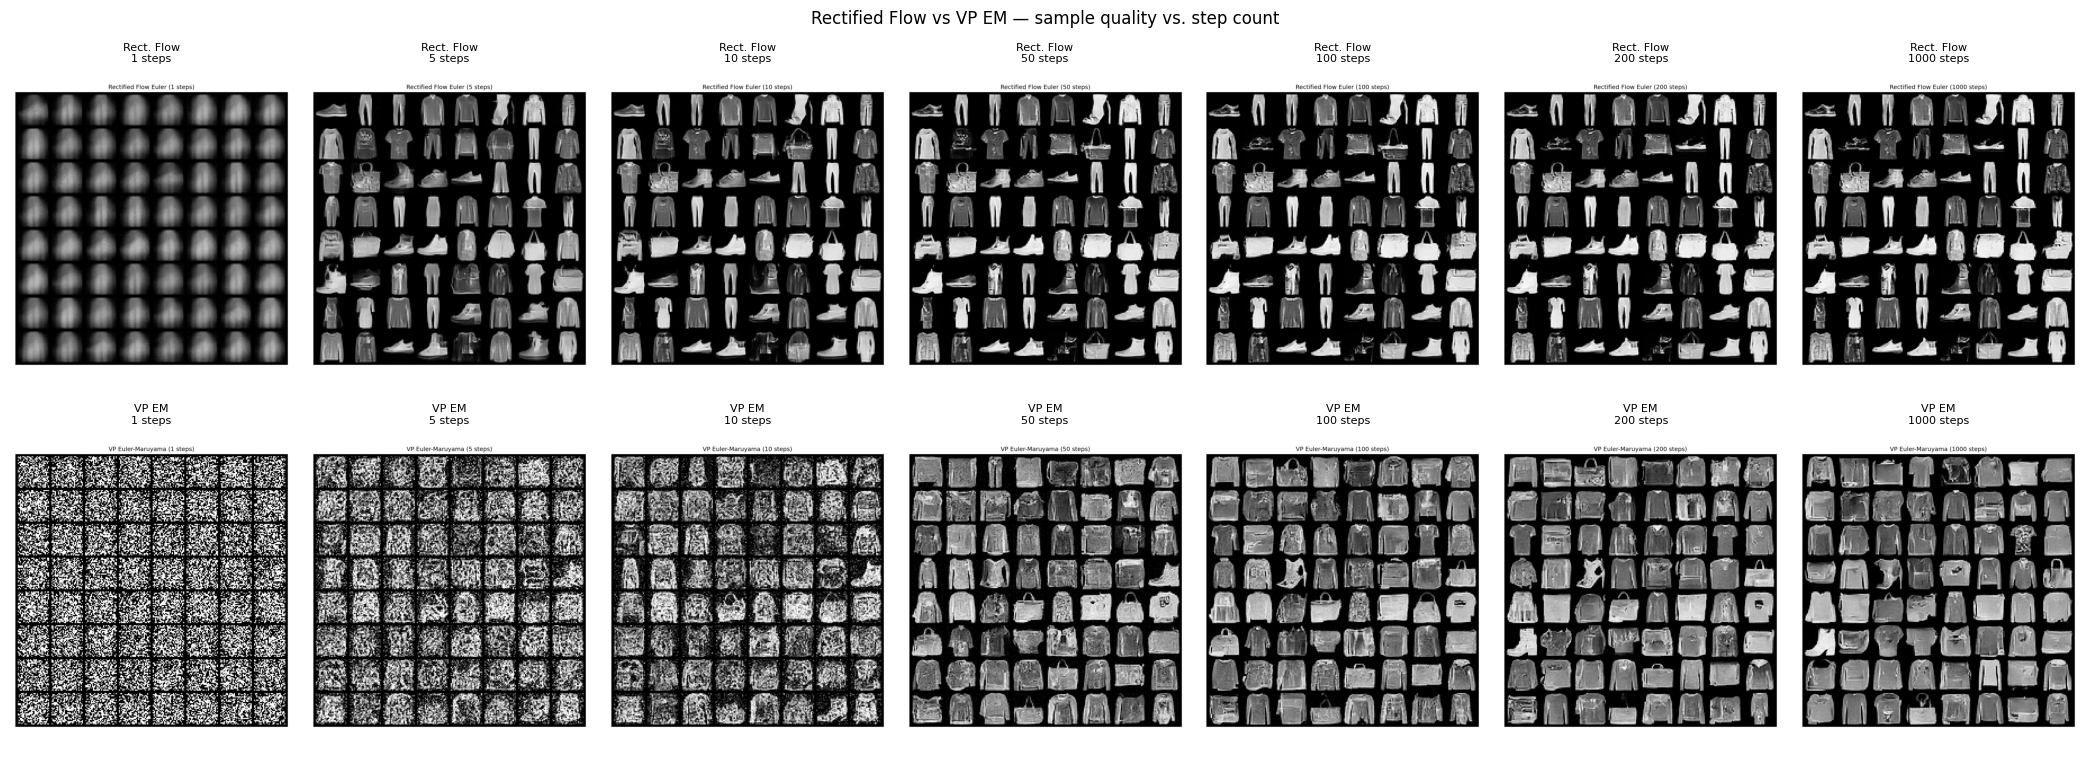

In [19]:
from IPython.display import Image, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

steps_list = [1, 5, 10, 50, 100, 200, 1000]

fig, axes = plt.subplots(2, len(steps_list), figsize=(3 * len(steps_list), 8))

for col, steps in enumerate(steps_list):
    for row, (method, label) in enumerate([
        (f"samples/rf_{steps}steps.png",    "Rect. Flow"),
        (f"samples/vp_em_{steps}steps.png", "VP EM"),
    ]):
        img = mpimg.imread(method)
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(f"{label}\n{steps} steps", fontsize=8)
        axes[row, col].axis("off")

plt.suptitle("Rectified Flow vs VP EM — sample quality vs. step count", fontsize=12)
plt.tight_layout()
plt.savefig("samples/comparison_steps.png", dpi=150)
plt.show()

## Problem 6.C: One-Step Generation after Reflow

Steps:
1. Generate 50k `(X̂₀, X̂₁)` pairs by running the trained ODE (100 Euler steps) from fresh noise.
2. Retrain for 20 epochs on those pairs.
3. Generate 64 samples with a **single** Euler step.

In [23]:
import os, glob, time

# Locate hw4 root and install diffusion package
hits = glob.glob("/content/**/scripts/train_rectflow.py", recursive=True)
if hits:
    hw4_root = os.path.dirname(os.path.dirname(hits[0]))
    %cd {hw4_root}

!pip install "numpy<2.0" -q
!pip install -e . --no-deps -q

os.makedirs("runs/rectflow_reflow", exist_ok=True)

# Step 1 & 2: generate 50k reflow pairs then retrain for 20 epochs
!python scripts/train_rectflow.py \
    --reflow \
    --checkpoint runs/rectflow/best.pt \
    --n_reflow_pairs 50000 \
    --reflow_steps 100 \
    --epochs 20 \
    --lr 1e-4 \
    --batch_size 128 \
    --save_dir runs/rectflow_reflow \
    --device cuda

/content/cs148_hw4
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for hw4 (pyproject.toml) ... done
Loaded checkpoint: runs/rectflow/best.pt
Generating 50000 reflow pairs ...
Reflow epoch   1/20 | loss 0.1846
Reflow epoch   2/20 | loss 0.0686
Reflow epoch   3/20 | loss 0.0505
Reflow epoch   4/20 | loss 0.0426
Reflow epoch   5/20 | loss 0.0364
Reflow epoch   6/20 | loss 0.0324
Reflow epoch   7/20 | loss 0.0293
Reflow epoch   8/20 | loss 0.0277
Reflow epoch   9/20 | loss 0.0252
Reflow epoch  10/20 | loss 0.0235
Reflow epoch  11/20 | loss 0.0226
Reflow epoch  12/20 | loss 0.0208
Reflow epoch  13/20 | loss 0.0206
Reflow epoch  14/20 | loss 0.0192
Reflow epoch  15/20 | loss 0.0193
Reflow epoch  16/20 | loss 0.0177
Reflow epoch  17/20 | loss 0.0175
Reflow epoch  18/20 | l

In [24]:
import time

os.makedirs("samples", exist_ok=True)

# Step 3: generate 64 one-step reflow samples and time it
t0 = time.time()
!python scripts/sample.py \
    --method rectflow \
    --checkpoint runs/rectflow_reflow/best.pt \
    --num_steps 1 \
    --n_samples 64 \
    --seed 0 \
    --out samples/reflow_1step.png \
    --device cuda
t1 = time.time()
print(f"Generation time for 64 samples: {t1 - t0:.2f}s")

# Also generate 1-step RF (without reflow) for comparison
!python scripts/sample.py \
    --method rectflow \
    --checkpoint runs/rectflow/best.pt \
    --num_steps 1 \
    --n_samples 64 \
    --seed 0 \
    --out samples/rf_1step_noreflow.png \
    --device cuda

Saved: samples/reflow_1step.png
Generation time for 64 samples: 5.82s
Saved: samples/rf_1step_noreflow.png


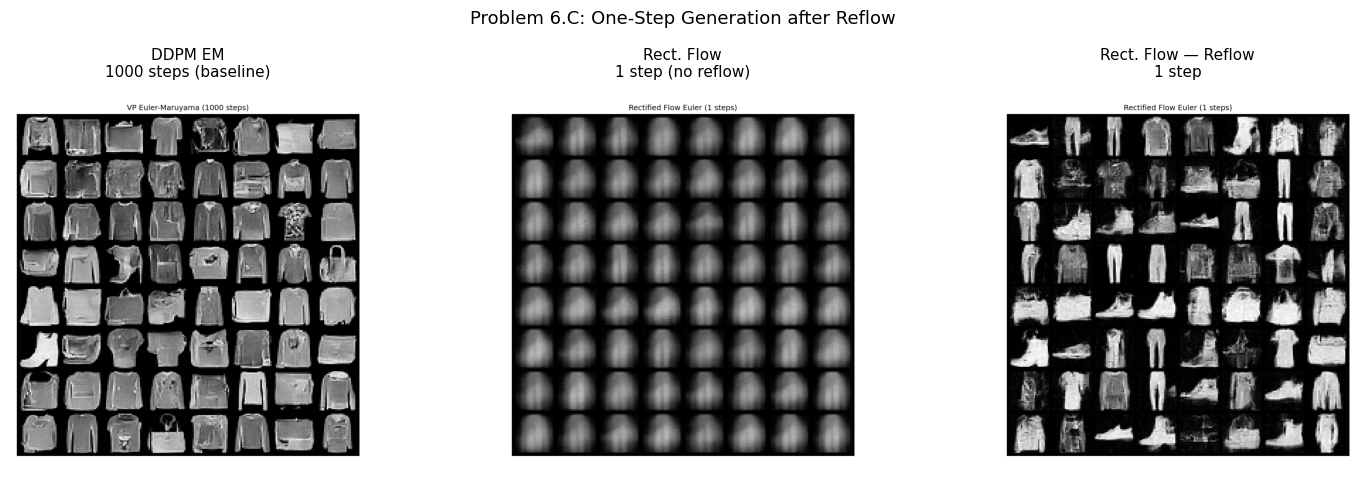

Saved 1000 real images to /tmp/kid_real_fuv1dtub
steps=    1 | RF  KID = 0.0576 ± 0.0000 | VP EM KID = 0.5540 ± 0.0000
steps=    5 | RF  KID = 0.0262 ± 0.0000 | VP EM KID = 0.4103 ± 0.0000
steps=   10 | RF  KID = 0.0221 ± 0.0000 | VP EM KID = 0.3405 ± 0.0000
steps=   50 | RF  KID = 0.0212 ± 0.0000 | VP EM KID = 0.0824 ± 0.0000
steps=  100 | RF  KID = 0.0202 ± 0.0000 | VP EM KID = 0.0576 ± 0.0000
steps=  200 | RF  KID = 0.0193 ± 0.0000 | VP EM KID = 0.0542 ± 0.0000
steps= 1000 | RF  KID = 0.0200 ± 0.0000 | VP EM KID = 0.0478 ± 0.0000

| Steps | Flow Matching | DDPM EM |
|------:|:-------------|:--------|
|     1 | 0.0576 ± 0.0000 | 0.5540 ± 0.0000 |
|     5 | 0.0262 ± 0.0000 | 0.4103 ± 0.0000 |
|    10 | 0.0221 ± 0.0000 | 0.3405 ± 0.0000 |
|    50 | 0.0212 ± 0.0000 | 0.0824 ± 0.0000 |
|   100 | 0.0202 ± 0.0000 | 0.0576 ± 0.0000 |
|   200 | 0.0193 ± 0.0000 | 0.0542 ± 0.0000 |
|  1000 | 0.0200 ± 0.0000 | 0.0478 ± 0.0000 ← baseline |


In [25]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

panels = [
    ("samples/vp_em_1000steps.png",   "DDPM EM\n1000 steps (baseline)"),
    ("samples/rf_1step_noreflow.png",  "Rect. Flow\n1 step (no reflow)"),
    ("samples/reflow_1step.png",       "Rect. Flow — Reflow\n1 step"),
]
for ax, (path, title) in zip(axes, panels):
    ax.imshow(mpimg.imread(path), cmap="gray")
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.suptitle("Problem 6.C: One-Step Generation after Reflow", fontsize=13)
plt.tight_layout()
plt.savefig("samples/6c_reflow_comparison.png", dpi=150)
plt.show()

# KID for reflow 1-step
!pip install torch-fidelity -q
!python scripts/eval_kid.py \
    --vp_checkpoint  runs/vp/best.pt \
    --rf_checkpoint  runs/rectflow_reflow/best.pt \
    --n_samples 1000 --device cuda

In [22]:
!pip install torch-fidelity -q
!python scripts/eval_kid.py \
    --vp_checkpoint runs/vp/best.pt \
    --rf_checkpoint runs/rectflow/best.pt \
    --n_samples 1000 --device cuda

Saved 1000 real images to /tmp/kid_real_yssr4rog
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
steps=    1 | RF  KID = 0.3668 ± 0.0000 | VP EM KID = 0.5538 ± 0.0000
steps=    5 | RF  KID = 0.0223 ± 0.0000 | VP EM KID = 0.4156 ± 0.0000
steps=   10 | RF  KID = 0.0089 ± 0.0000 | VP EM KID = 0.3391 ± 0.0000
steps=   50 | RF  KID = 0.0058 ± 0.0000 | VP EM KID = 0.0883 ± 0.0000
steps=  100 | RF  KID = 0.0059 ± 0.0000 | VP EM KID = 0.0600 ± 0.0000
steps=  200 | RF  KID = 0.0056 ± 0.0000 | VP EM KID = 0.0502 ± 0.0000
steps= 1000 | RF  KID = 0.0074 ± 0.0000 | VP EM KID = 0.0460 ± 0.0000

| Steps | Flow Matching | DDPM EM |
|------:|:-------------|:--------|
|     1 | 0.3668 ± 0.0000 | 0.5538 ± 0.0000 |
|     5 | 0.0223 ± 0.0000 | 0.4156 ± 0.0000 |
|    10 | 0.0089 ± 0.0000 | 0.3391 ± 0.0000 |
|    50 | 0.0058 ± 0.0000 | 0.0883 ± 0.0000 |
| 

## Problem 6.D: Side-by-Side Qualitative Grid (4 × 8)

In [26]:
import os
os.makedirs("samples", exist_ok=True)

# Generate 4×8 side-by-side grid with 8 fixed seeds across all four methods:
#   Row 1: DDPM EM (1000 steps)
#   Row 2: Rect. Flow (100 steps)
#   Row 3: Rect. Flow (1 step)
#   Row 4: Reflow (1 step)
!python scripts/sample.py \
    --method all \
    --vp_checkpoint      runs/vp/best.pt \
    --rf_checkpoint      runs/rectflow/best.pt \
    --reflow_checkpoint  runs/rectflow_reflow/best.pt \
    --beta_min 0.01 --beta_max 5.0 \
    --n_samples 8 \
    --seed 42 \
    --out samples/6d_comparison_grid.png \
    --device cuda

Saved: samples/6d_comparison_grid.png
Row order: ['DDPM EM (1000 steps)', 'Rect. Flow (100 steps)', 'Rect. Flow (1 step)', 'Reflow (1 step)']


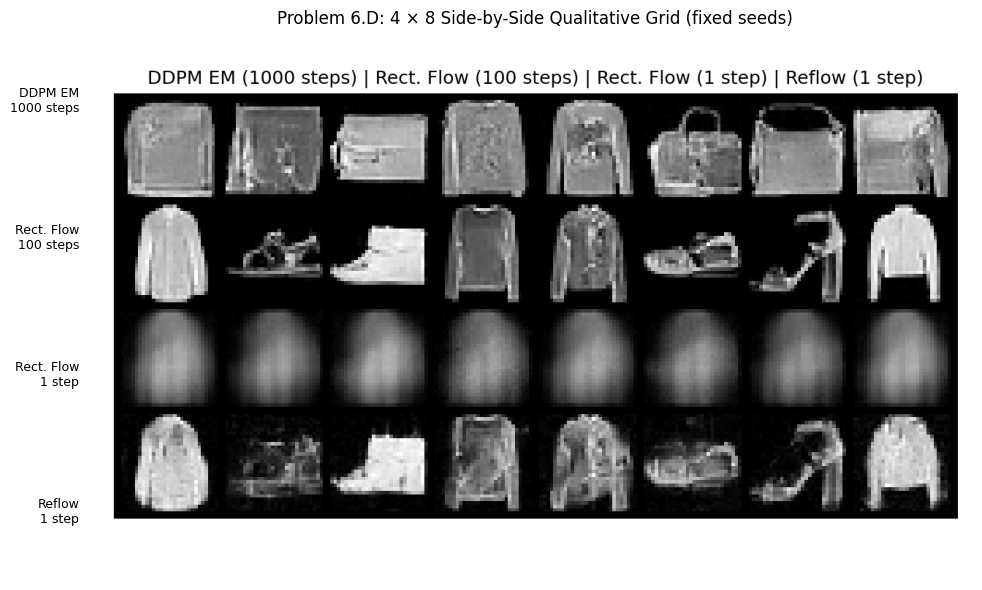

In [27]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("samples/6d_comparison_grid.png")

fig, ax = plt.subplots(figsize=(16, 6))
ax.imshow(img, cmap="gray")
ax.axis("off")

# Add row labels on the left
row_labels = ["DDPM EM\n1000 steps", "Rect. Flow\n100 steps",
              "Rect. Flow\n1 step",   "Reflow\n1 step"]
h = img.shape[0]
for i, label in enumerate(row_labels):
    y = (i + 0.5) * h / 4
    ax.text(-img.shape[1] * 0.02, y, label, va="center", ha="right",
            fontsize=9, transform=ax.transData)

plt.title("Problem 6.D: 4 × 8 Side-by-Side Qualitative Grid (fixed seeds)", fontsize=12)
plt.tight_layout()
plt.savefig("samples/6d_comparison_grid_labeled.png", dpi=150, bbox_inches="tight")
plt.show()

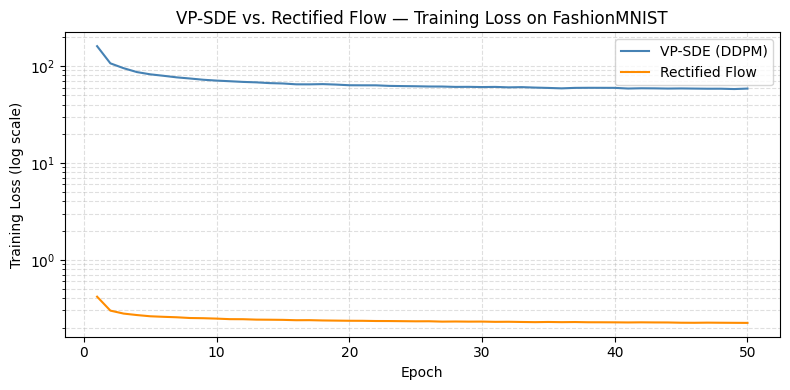

Final VP  loss : 58.4796
Final RF  loss : 0.2234


In [43]:
import numpy as np
import matplotlib.pyplot as plt

# ── Load loss curves (adjust paths if your save_dir differs) ──────────────────
vp_losses   = np.load("runs/vp/train_losses.npy")        # VP  losses saved by train_vp.py
rf_losses   = np.load("runs/rectflow/train_losses.npy")  # RF  losses saved by train_rectflow.py

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.semilogy(range(1, len(vp_losses) + 1), vp_losses, label="VP-SDE (DDPM)", color="steelblue")
ax.semilogy(range(1, len(rf_losses) + 1), rf_losses, label="Rectified Flow", color="darkorange")

ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss (log scale)")
ax.set_title("VP-SDE vs. Rectified Flow — Training Loss on FashionMNIST")
ax.legend()
ax.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/combined_loss_curves.png", dpi=150)
plt.show()

print(f"Final VP  loss : {vp_losses[-1]:.4f}")
print(f"Final RF  loss : {rf_losses[-1]:.4f}")

# Part 5: Diffusion models on a larger scale

As mentioned in the write-up, you only need to include your code for plotting in this notebook for part 5. Here we provide some helper code if you run the experiments here in Google Colab.

### Helper code

In [30]:
%%bash
# Clone and install guided-diffusion directly in /content (no Drive needed)
if [ ! -d /content/guided-diffusion ]; then
    git clone https://github.com/openai/guided-diffusion /content/guided-diffusion
fi
cd /content/guided-diffusion
pip install -e . -q
pip install blobfile mpi4py -q

mkdir -p models
# Download weights (~2GB each — skip if already present)
[ ! -f models/256x256_diffusion_uncond.pt ] && \
    wget -q https://openaipublic.blob.core.windows.net/diffusion/jul-2021/256x256_diffusion_uncond.pt -P models/
[ ! -f models/256x256_classifier.pt ] && \
    wget -q https://openaipublic.blob.core.windows.net/diffusion/jul-2021/256x256_classifier.pt -P models/

# Move sample scripts to working directory so Python can find them
cp scripts/classifier_sample.py . 2>/dev/null || true
cp scripts/image_sample.py      . 2>/dev/null || true
echo "Setup complete."

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.2 MB/s eta 0:00:00
Setup complete.


Cloning into '/content/guided-diffusion'...


#### Change the directory (TODO)

In [31]:
# All guided-diffusion work lives here — no Drive needed
directory = '/content/guided-diffusion'
%cd {directory}

/content/guided-diffusion


In [32]:
# Weights were already downloaded in the setup cell above.
# Verify they exist:
import os
for f in ['models/256x256_diffusion_uncond.pt', 'models/256x256_classifier.pt']:
    status = "✓" if os.path.exists(f) else "✗ MISSING"
    print(f"{status}  {f}")

✓  models/256x256_diffusion_uncond.pt
✓  models/256x256_classifier.pt


In [33]:
!mv scripts/classifier_sample.py classifier_sample.py

#### Example code for running a script

In [ ]:
import os
# specify directory to save samples
os.environ['OPENAI_LOGDIR'] = '/content/test'

In [ ]:
# define flags
SAMPLE_FLAGS = """
    --batch_size 1
    --num_samples 2
    --timestep_respacing 250
"""
MODEL_FLAGS = """
    --attention_resolutions 32,16,8
    --class_cond False
    --diffusion_steps 1000
    --image_size 256
    --learn_sigma True
    --noise_schedule linear
    --num_channels 256
    --num_head_channels 64
    --num_res_blocks 2
    --resblock_updown True
    --use_fp16 True
    --use_scale_shift_norm True
"""

# run a script
!python classifier_sample.py {MODEL_FLAGS.replace('\n', '')} \
    --classifier_scale 10.0 \
    --classifier_path models/256x256_classifier.pt \
    --model_path models/256x256_diffusion_uncond.pt \
    {SAMPLE_FLAGS.replace('\n', '')}

### A: unconditional generation

In [34]:
import os, sys
sys.path.insert(0, directory)   # make guided-diffusion importable

os.environ['OPENAI_LOGDIR'] = '/content/outputs/7_1_uncond'
os.makedirs(os.environ['OPENAI_LOGDIR'], exist_ok=True)

MODEL_FLAGS = """
    --attention_resolutions 32,16,8 --class_cond False
    --diffusion_steps 1000 --image_size 256 --learn_sigma True
    --noise_schedule linear --num_channels 256 --num_head_channels 64
    --num_res_blocks 2 --resblock_updown True --use_fp16 True
    --use_scale_shift_norm True
"""
SAMPLE_FLAGS = """
    --batch_size 8 --num_samples 8 --timestep_respacing 250
"""

!python image_sample.py {MODEL_FLAGS.replace(chr(10),'')} \
    --model_path {directory}/models/256x256_diffusion_uncond.pt \
    {SAMPLE_FLAGS.replace(chr(10),'')}

# ── Plot ──────────────────────────────────────────────────────────────────────
import glob as _glob
npz = sorted(_glob.glob(os.path.join(os.environ['OPENAI_LOGDIR'], '*.npz')))[-1]
print("NPZ:", npz)

import sys; sys.path.insert(0, '/content/cs148_hw4')
from scripts.guided_diffusion_experiments import plot_unconditional
plot_unconditional(npz, out='/content/outputs/7_1_uncond.png')

Logging to /content/outputs/7_1_uncond
creating model and diffusion...
sampling...
created 8 samples
saving to /content/outputs/7_1_uncond/samples_8x256x256x3.npz
/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)
sampling complete
[rank0]:[W526 00:16:14.162710024 ProcessGroupNCCL.cpp:1553] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())
NPZ: /content/outputs/7_1_uncond/samples_8x256x256x3.npz
Saved: /content/outputs/7_1_uncond.png


### B: progression over time visualization

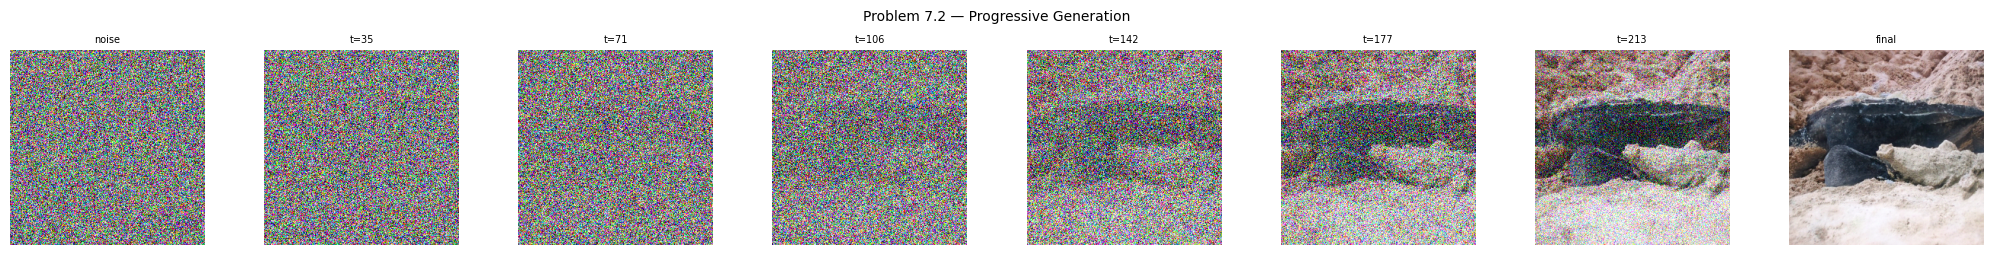

Saved: /content/outputs/7_2_progressive.png


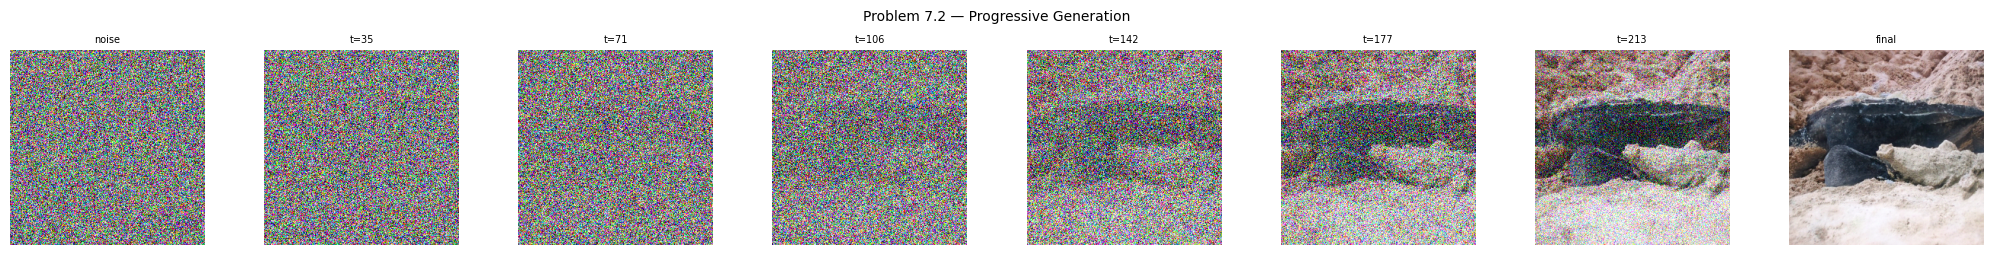

Saved: /content/outputs/7_2_progressive.png


In [36]:
import os, sys, torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '/content/guided-diffusion')
from guided_diffusion.script_util import (
    model_and_diffusion_defaults, create_model_and_diffusion
)

# ── Build args by starting from defaults and overriding only what we need ─────
defaults = model_and_diffusion_defaults()
overrides = dict(
    attention_resolutions="32,16,8", class_cond=False, diffusion_steps=1000,
    image_size=256, learn_sigma=True, noise_schedule="linear",
    num_channels=256, num_head_channels=64, num_res_blocks=2,
    resblock_updown=True, use_fp16=True, use_scale_shift_norm=True,
    timestep_respacing="250",
)
# Only override keys that actually exist in defaults to avoid unexpected-kwarg errors
for k, v in overrides.items():
    if k in defaults:
        defaults[k] = v

model, diffusion = create_model_and_diffusion(**defaults)
model.load_state_dict(torch.load('/content/guided-diffusion/models/256x256_diffusion_uncond.pt',
                                  map_location='cpu'))
model.to('cuda').eval()
if overrides['use_fp16']:
    model.convert_to_fp16()

# ── Collect all intermediate frames via the progressive loop ──────────────────
torch.manual_seed(42)
noise = torch.randn(1, 3, 256, 256, device='cuda')

all_frames = []
for sample in diffusion.p_sample_loop_progressive(
        model, (1, 3, 256, 256),
        noise=noise,
        clip_denoised=True,
        model_kwargs={}):
    all_frames.append(sample['sample'].cpu())

# Pick 8 evenly spaced frames (0 = most noise, last = clean)
indices = np.linspace(0, len(all_frames) - 1, 8, dtype=int)
frames  = [all_frames[i] for i in indices]

# ── Plot 256×2048 figure ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 8, figsize=(20.48, 2.56))
for col, (ax, frame) in enumerate(zip(axes, frames)):
    img = frame[0].permute(1, 2, 0).numpy()
    img = (img * 127.5 + 127.5).clip(0, 255).astype(np.uint8)
    ax.imshow(img)
    ax.axis('off')
    label = 'noise' if col == 0 else ('final' if col == 7 else f't={indices[col]}')
    ax.set_title(label, fontsize=7)

fig.suptitle('Problem 7.2 — Progressive Generation', fontsize=10)
plt.tight_layout()
os.makedirs('/content/outputs', exist_ok=True)
plt.savefig('/content/outputs/7_2_progressive.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: /content/outputs/7_2_progressive.png')

# ── Collect 8 evenly-spaced intermediate frames via the progressive loop ──────
torch.manual_seed(42)
noise = torch.randn(1, 3, 256, 256, device='cuda')

all_frames = []   # list of (1, C, H, W) tensors
for sample in diffusion.p_sample_loop_progressive(
        model, (1, 3, 256, 256),
        noise=noise,
        clip_denoised=True,
        model_kwargs={}):
    all_frames.append(sample['sample'].cpu())

# Pick 8 evenly spaced frames (index 0 = most noise, last = clean)
indices = np.linspace(0, len(all_frames) - 1, 8, dtype=int)
frames  = [all_frames[i] for i in indices]

# ── Plot 256×2048 figure ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 8, figsize=(20.48, 2.56))
for col, (ax, frame) in enumerate(zip(axes, frames)):
    img = frame[0].permute(1, 2, 0).numpy()
    img = (img * 127.5 + 127.5).clip(0, 255).astype(np.uint8)
    ax.imshow(img)
    ax.axis('off')
    label = 'noise' if col == 0 else ('final' if col == 7 else f't={indices[col]}')
    ax.set_title(label, fontsize=7)

fig.suptitle('Problem 7.2 — Progressive Generation', fontsize=10)
plt.tight_layout()

os.makedirs('/content/outputs', exist_ok=True)
plt.savefig('/content/outputs/7_2_progressive.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: /content/outputs/7_2_progressive.png')

### C: interpolation visualization

Selected seeds: z0=candidate 1, z7=candidate 5  (rough pixel distance=401206.7)


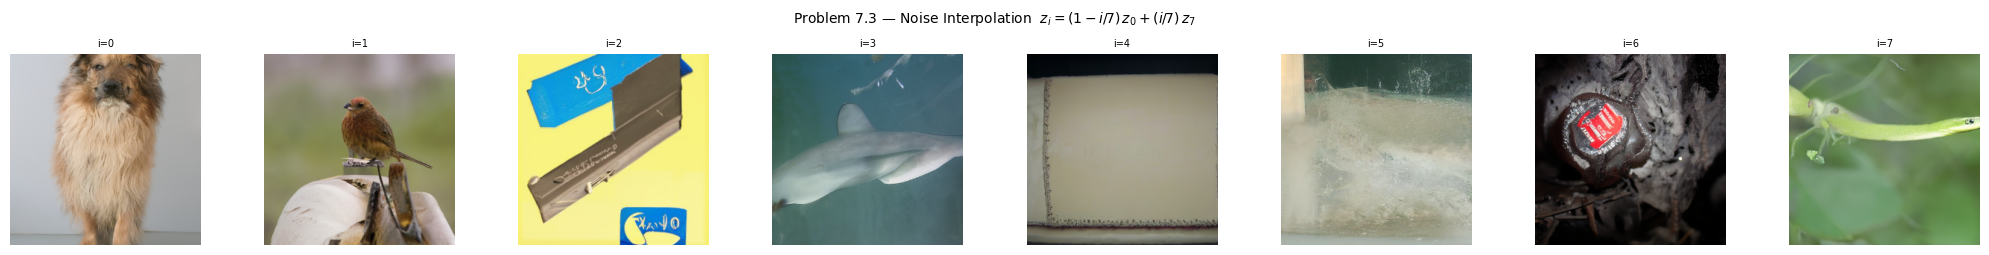

Saved: /content/outputs/7_3_interpolation.png


In [37]:
import os, torch
import numpy as np
import matplotlib.pyplot as plt

# model and diffusion are already loaded from the 7.2 cell above.
# If re-running standalone, re-run the 7.2 cell first.

# ── Pick z0 and z7 to be as different as possible ─────────────────────────────
# Strategy: sample a small pool of noise vectors, run a quick 1-step decode
# to get rough image estimates, then pick the pair with maximum L2 distance.
N_CANDIDATES = 8
torch.manual_seed(0)
candidates = torch.randn(N_CANDIDATES, 3, 256, 256, device='cuda')

# Quick single-step "decode" to get a rough image estimate for each candidate
with torch.no_grad():
    t_last = torch.tensor([0], device='cuda')
    rough  = [model(candidates[i:i+1], t_last).cpu() for i in range(N_CANDIDATES)]

# Find the pair with the largest L2 distance in pixel space
best_dist, best_i, best_j = 0, 0, 1
for i in range(N_CANDIDATES):
    for j in range(i + 1, N_CANDIDATES):
        d = (rough[i] - rough[j]).pow(2).sum().item()
        if d > best_dist:
            best_dist, best_i, best_j = d, i, j

z0 = candidates[best_i:best_i+1]   # (1, 3, 256, 256)
z7 = candidates[best_j:best_j+1]

print(f"Selected seeds: z0=candidate {best_i}, z7=candidate {best_j}  "
      f"(rough pixel distance={best_dist:.1f})")

# ── Generate 8 interpolated samples ───────────────────────────────────────────
results = []
for i in range(8):
    alpha = i / 7.0
    z_i   = (1 - alpha) * z0 + alpha * z7          # linear interpolation

    with torch.no_grad():
        sample = diffusion.p_sample_loop(
            model, (1, 3, 256, 256),
            noise=z_i,
            clip_denoised=True,
            model_kwargs={},
        )
    results.append(sample.cpu())

# ── Plot 256×2048 figure ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 8, figsize=(20.48, 2.56))
for col, (ax, s) in enumerate(zip(axes, results)):
    img = s[0].permute(1, 2, 0).numpy()
    img = (img * 127.5 + 127.5).clip(0, 255).astype(np.uint8)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'i={col}', fontsize=7)

fig.suptitle('Problem 7.3 — Noise Interpolation  '
             r'$z_i = (1 - i/7)\,z_0 + (i/7)\,z_7$', fontsize=10)
plt.tight_layout()
os.makedirs('/content/outputs', exist_ok=True)
plt.savefig('/content/outputs/7_3_interpolation.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: /content/outputs/7_3_interpolation.png')

### D: conditional generation

Generating class 1: goldfish
Logging to /content/outputs/7_4_cond/class_1
creating model and diffusion...
loading classifier...
sampling...
created 1 samples
saving to /content/outputs/7_4_cond/class_1/samples_1x256x256x3.npz
/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)
sampling complete
[rank0]:[W526 00:45:14.485784968 ProcessGroupNCCL.cpp:1553] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())
Generating class 10: ostrich
Logging to /content/outputs/7_4_cond/class_10
creating model and diffusion...
loading classifier...
sampling...
created 1 samples
saving to /content/outputs/7_4_cond/class_10/samples_1x256x256x3.npz
/usr/local/l

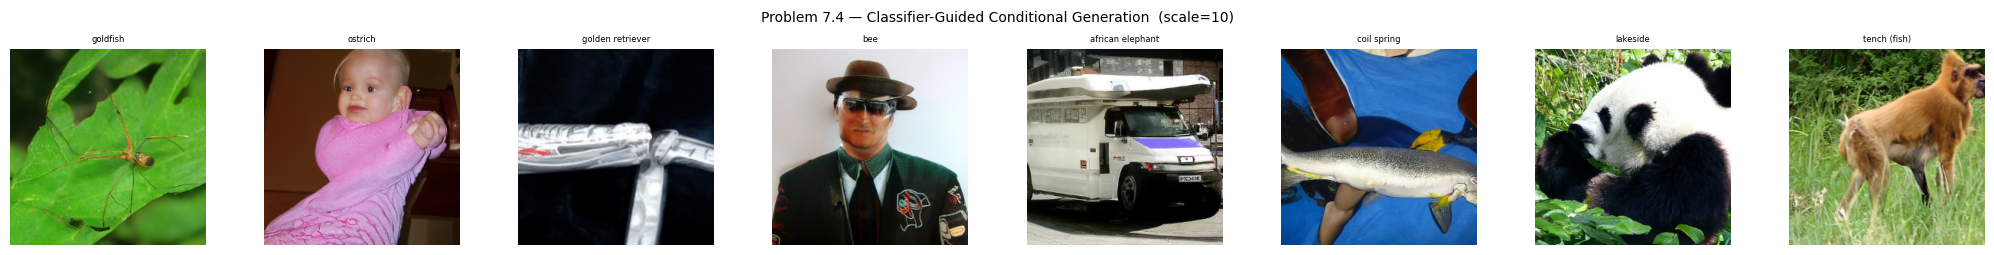

Saved: /content/outputs/7_4_conditional.png


In [39]:
import os, torch
import numpy as np
import matplotlib.pyplot as plt
import glob as _glob

# 8 diverse ImageNet classes (manually chosen for visual variety)
CLASS_IDS   = [1, 10, 207, 309, 385, 504, 614, 843]
CLASS_NAMES = [
    "goldfish", "ostrich", "golden retriever", "bee",
    "african elephant", "coil spring", "lakeside", "tench (fish)"
]

# NOTE: use --class_cond False — the diffusion model is unconditional.
# Class conditioning comes purely from the classifier gradient.
MODEL_FLAGS = (
    "--attention_resolutions 32,16,8 --class_cond False "
    "--diffusion_steps 1000 --image_size 256 --learn_sigma True "
    "--noise_schedule linear --num_channels 256 --num_head_channels 64 "
    "--num_res_blocks 2 --resblock_updown True --use_fp16 True "
    "--use_scale_shift_norm True"
)
CLASSIFIER_FLAGS = (
    "--image_size 256 --classifier_attention_resolutions 32,16,8 "
    "--classifier_depth 2 --classifier_width 128 "
    "--classifier_pool attention --classifier_resblock_updown True "
    "--classifier_use_scale_shift_norm True"
)

for cls_id, cls_name in zip(CLASS_IDS, CLASS_NAMES):
    out_dir = f'/content/outputs/7_4_cond/class_{cls_id}'
    os.makedirs(out_dir, exist_ok=True)
    os.environ['OPENAI_LOGDIR'] = out_dir
    print(f"Generating class {cls_id}: {cls_name}")
    !python classifier_sample.py {MODEL_FLAGS} {CLASSIFIER_FLAGS} \
        --classifier_scale 10.0 \
        --classifier_path /content/guided-diffusion/models/256x256_classifier.pt \
        --model_path      /content/guided-diffusion/models/256x256_diffusion_uncond.pt \
        --batch_size 1 --num_samples 1 --timestep_respacing 250

# ── Load and plot all 8 results ───────────────────────────────────────────────
results = []
for cls_id in CLASS_IDS:
    npz_files = sorted(_glob.glob(f'/content/outputs/7_4_cond/class_{cls_id}/*.npz'))
    img = np.load(npz_files[-1])['arr_0'][0]
    results.append(img)

fig, axes = plt.subplots(1, 8, figsize=(20.48, 2.56))
for ax, img, name in zip(axes, results, CLASS_NAMES):
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(name, fontsize=6)

fig.suptitle('Problem 7.4 — Classifier-Guided Conditional Generation  (scale=10)', fontsize=10)
plt.tight_layout()
plt.savefig('/content/outputs/7_4_conditional.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: /content/outputs/7_4_conditional.png')

### E: conditional generation with different classifier scales

scale=0.5
Logging to /content/outputs/7_5_sweep/scale_0.5
creating model and diffusion...
loading classifier...
sampling...
created 2 samples
saving to /content/outputs/7_5_sweep/scale_0.5/samples_2x256x256x3.npz
/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)
sampling complete
[rank0]:[W526 01:00:26.734319411 ProcessGroupNCCL.cpp:1553] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())
scale=1.0
Logging to /content/outputs/7_5_sweep/scale_1.0
creating model and diffusion...
loading classifier...
sampling...
created 2 samples
saving to /content/outputs/7_5_sweep/scale_1.0/samples_2x256x256x3.npz
/usr/local/lib/python3.12/dist-packages/

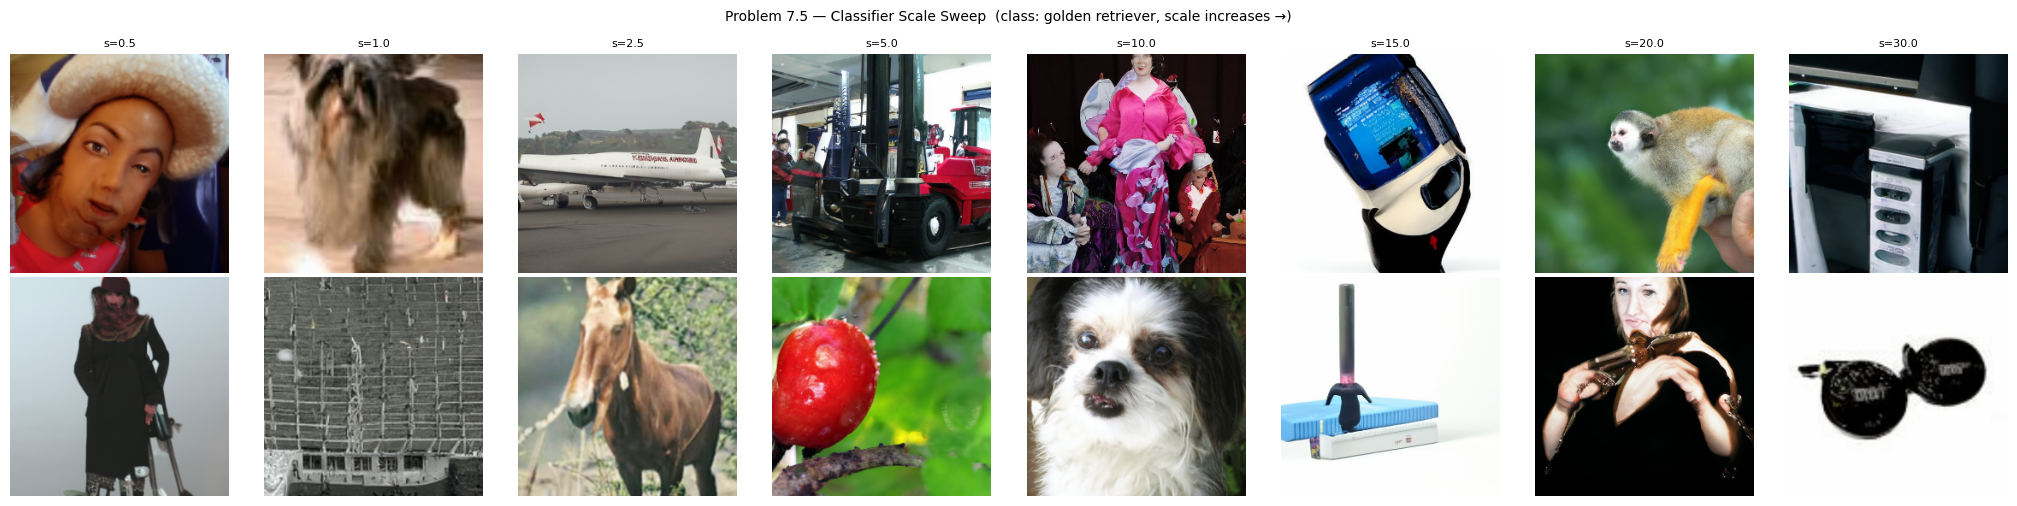

Saved: /content/outputs/7_5_scale_sweep.png


In [40]:
import os, numpy as np, matplotlib.pyplot as plt, glob as _glob

# 8 monotonically increasing classifier scales
SCALES     = [0.5, 1.0, 2.5, 5.0, 10.0, 15.0, 20.0, 30.0]
# Fixed class and seed for all columns
CLASS_ID   = 207    # golden retriever
SEED       = 42

MODEL_FLAGS = (
    "--attention_resolutions 32,16,8 --class_cond False "
    "--diffusion_steps 1000 --image_size 256 --learn_sigma True "
    "--noise_schedule linear --num_channels 256 --num_head_channels 64 "
    "--num_res_blocks 2 --resblock_updown True --use_fp16 True "
    "--use_scale_shift_norm True"
)
CLASSIFIER_FLAGS = (
    "--image_size 256 --classifier_attention_resolutions 32,16,8 "
    "--classifier_depth 2 --classifier_width 128 "
    "--classifier_pool attention --classifier_resblock_updown True "
    "--classifier_use_scale_shift_norm True"
)

# Generate 2 samples per scale (same seed → same initial noise across all scales)
for scale in SCALES:
    out_dir = f'/content/outputs/7_5_sweep/scale_{scale}'
    os.makedirs(out_dir, exist_ok=True)
    os.environ['OPENAI_LOGDIR'] = out_dir
    print(f"scale={scale}")
    !python classifier_sample.py {MODEL_FLAGS} {CLASSIFIER_FLAGS} \
        --classifier_scale {scale} \
        --classifier_path /content/guided-diffusion/models/256x256_classifier.pt \
        --model_path      /content/guided-diffusion/models/256x256_diffusion_uncond.pt \
        --batch_size 2 --num_samples 2 --timestep_respacing 250

# ── Load results and build 2-row × 8-col figure ───────────────────────────────
rows = [[], []]
for scale in SCALES:
    npz  = sorted(_glob.glob(f'/content/outputs/7_5_sweep/scale_{scale}/*.npz'))[-1]
    imgs = np.load(npz)['arr_0']    # (2, H, W, 3) uint8
    rows[0].append(imgs[0])
    rows[1].append(imgs[1])

fig, axes = plt.subplots(2, 8, figsize=(20.48, 5.12))
for row in range(2):
    for col, (ax, img) in enumerate(zip(axes[row], rows[row])):
        ax.imshow(img)
        ax.axis('off')
        if row == 0:
            ax.set_title(f's={SCALES[col]}', fontsize=8)

fig.suptitle(
    'Problem 7.5 — Classifier Scale Sweep  (class: golden retriever, scale increases →)',
    fontsize=10)
plt.tight_layout()
plt.savefig('/content/outputs/7_5_scale_sweep.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: /content/outputs/7_5_scale_sweep.png')